# Zero-temperature amplitude damping channel — noisy

This notebook adds the first-tier NISQ-style noise layer on top of the same
analytic-SVD amplitude-damping workflow.

Main things to tweak:
- `gamma`
- the time grid
- `shots`
- the entries of `noise_params`


In [15]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from timeevo.ampdamp.ampdamp_channel import (
    analytic_svd_for_amplitude_damping,
    amplitude_damping_kraus_operators,
    exact_amplitude_damping_density_matrix,
    exact_coherence_formula,
    exact_population_formula,
    paper_initial_density_matrix,
    paper_initial_state_decomposition,
    paper_time_grid,
    simulate_amplitude_damping_trajectory,
)

from plot.coherence_plot import (plot_coherence_comparison, plot_populations_and_coherence_comparison, )
from noise.noise_simulation import SimpleNISQNoiseParameters

In [16]:
# Tweakable parameters
gamma = 0.015
times = paper_time_grid(t_max=50.0, num_points=26)
shots = 32000
seed = 11

noise_params = SimpleNISQNoiseParameters(
    t1_system=80.0,
    t2_system=60.0,
    t1_ancilla=70.0,
    t2_ancilla=50.0,
    one_qubit_gate_time=0.035,
    two_qubit_gate_time=0.25,
    p1q_depolarizing=0.001,
    p2q_depolarizing=0.01,
    readout_p0_to_1_system=0.01,
    readout_p1_to_0_system=0.03,
    readout_p0_to_1_ancilla=0.01,
    readout_p1_to_0_ancilla=0.03,
)


## Inspect the analytic SVD and Kraus operators at one time

In [17]:
t_inspect = 8.0

K0, K1 = amplitude_damping_kraus_operators(t_inspect, gamma=gamma)
svd0 = analytic_svd_for_amplitude_damping(t_inspect, branch=0, gamma=gamma)
svd1 = analytic_svd_for_amplitude_damping(t_inspect, branch=1, gamma=gamma)

print("K0 =\n", K0)
print("K1 =\n", K1)
print()
print("Reconstructed K0 max error =", np.max(np.abs(svd0.reconstruct() - K0)))
print("Reconstructed K1 max error =", np.max(np.abs(svd1.reconstruct() - K1)))


K0 =
 [[1.        +0.j 0.        +0.j]
 [0.        +0.j 0.94176453+0.j]]
K1 =
 [[0.        +0.j 0.33627305+0.j]
 [0.        +0.j 0.        +0.j]]

Reconstructed K0 max error = 0.0
Reconstructed K1 max error = 0.0


## Simulate the noisy trajectory

In [18]:
result = simulate_amplitude_damping_trajectory(
    times,
    gamma=gamma,
    shots=shots,
    seed=seed,
    noise_params=noise_params,
)

print("Exact rho(t=0) =\n", result.exact_density_matrices[0])
print()
print("Obtained rho(t=0) =\n", result.obtained_density_matrices[0])


Exact rho(t=0) =
 [[0.25+0.j 0.25+0.j]
 [0.25+0.j 0.75+0.j]]

Obtained rho(t=0) =
 [[0.27886993+0.j         0.24653862-0.00766115j]
 [0.24653862+0.00766115j 0.72113007+0.j        ]]


## Population & Coherence plot: exact curve and noisy obtained data

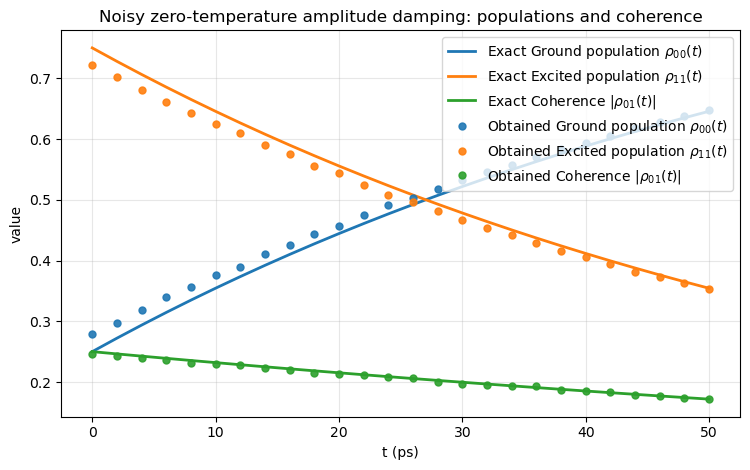

In [19]:
fig, ax = plot_populations_and_coherence_comparison(
    times,
    result.exact_density_matrices,
    result.obtained_density_matrices,
    coherence_component="abs",   # change to "imag", "abs", or "phase" if desired
    colors=["tab:blue", "tab:orange", "tab:green"],
    title="Noisy zero-temperature amplitude damping: populations and coherence",
    xlabel="t (ps)",
)
plt.show()


## Saves the figure

In [20]:
out_dir = Path.cwd()
fig.savefig(out_dir / 'ampdamp_noisy_population_coherence.png', dpi=200, bbox_inches='tight')
plt.close(fig)



## Optional: separate coherence-only plot

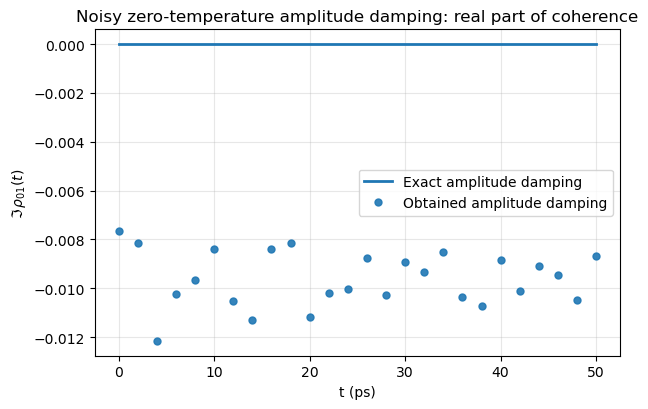

In [21]:
fig, ax = plot_coherence_comparison(
    result.coherence_exact,
    result.coherence_obtained,
    component="imag",   # change to "imag", "abs", "phase", or "complex"
    title="Noisy zero-temperature amplitude damping: real part of coherence",
    xlabel="t (ps)",
)
plt.show()
